In [12]:
# Install required packages
#%pip install -qq netcdf4 xarray harmony-py python-cmr geopandas wget
%pip install -qq pandas xarray matplotlib netcdf4 pyproj pyrsig pycno thefuzz

Note: you may need to restart the kernel to use updated packages.


In [13]:
# Load packages into current runtime
import datetime as dt
import geopandas as gpd

import cmr
import wget
import os

# Import Libraries
import pyrsig
import pandas as pd
import pycno
import getpass
import matplotlib.pyplot as plt
from collections import defaultdict
import re
from thefuzz import process, fuzz

In [14]:
# Get United States urban areas shapefile
# This is written to be used on a linux machine, might not work on mac
if(not os.path.isdir("city_shapefile")):
    os.makedirs("city_shapefile")
    wget.download("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_ua10_500k.zip", out="./city_shapefile")
    !unzip city_shapefile/* -d ./city_shapefile
    !rm city_shapefile/*.zip

gdf_cities = gpd.read_file("city_shapefile/")

#  Verify the cities were loaded correctly
city_names = gdf_cities['NAME10']
print(city_names)

Archive:  city_shapefile/cb_2018_us_ua10_500k.zip
  inflating: ./city_shapefile/cb_2018_us_ua10_500k.shp.ea.iso.xml  
  inflating: ./city_shapefile/cb_2018_us_ua10_500k.shp.iso.xml  
  inflating: ./city_shapefile/cb_2018_us_ua10_500k.shp  
  inflating: ./city_shapefile/cb_2018_us_ua10_500k.shx  
  inflating: ./city_shapefile/cb_2018_us_ua10_500k.dbf  
  inflating: ./city_shapefile/cb_2018_us_ua10_500k.prj  
 extracting: ./city_shapefile/cb_2018_us_ua10_500k.cpg  
0                      Tucson, AZ
1                     Alturas, CA
2               Davenport, IA--IL
3              Waynesboro, PA--MD
4                      Angola, IN
                  ...            
3596                   Milton, DE
3597          Sugarmill Woods, FL
3598    Lake Conroe Eastshore, TX
3599                 Checotah, OK
3600        De Funiak Springs, FL
Name: NAME10, Length: 3601, dtype: object


In [15]:
# Populates a dictionary that converts a states two-letter post code into a fips code
postal_to_fips = dict()
with open("fips.txt", "r") as file:
    for line in file:
        # Uses list comprehension to only get the entries that are 2 uppercase letters
        line = [s for s in re.split("\t| ", line[:-1]) if len(s) == 2 and s.upper() == s]
        postal_to_fips[line[0]] = line[1]

print(postal_to_fips)

{'AL': '01', 'NE': '31', 'AK': '02', 'NV': '32', 'AZ': '04', 'NH': '33', 'AR': '05', 'NJ': '34', 'CA': '06', 'NM': '35', 'CO': '08', 'NY': '36', 'CT': '09', 'NC': '37', 'DE': '10', 'ND': '38', 'DC': '11', 'OH': '39', 'FL': '12', 'OK': '40', 'GA': '13', 'OR': '41', 'HI': '15', 'PA': '42', 'ID': '16', 'PR': '72', 'IL': '17', 'RI': '44', 'IN': '18', 'SC': '45', 'IA': '19', 'SD': '46', 'KS': '20', 'TN': '47', 'KY': '21', 'TX': '48', 'LA': '22', 'UT': '49', 'ME': '23', 'VT': '50', 'MD': '24', 'VA': '51', 'MA': '25', 'VI': '78', 'MI': '26', 'WA': '53', 'MN': '27', 'WV': '54', 'MS': '28', 'WI': '55', 'MO': '29', 'WY': '56', 'MT': '30'}


In [16]:
# Uses fuzzy pattern matching to try to best approximate the city the user wants to laod
# Works pretty well, but some cities are annoying syntactically
# (e.g "washington dc" outputs "washington nc," you have to put "washington d.c")
def get_best_match(queryString: str) -> str:
    min_match = 60
    # ensure that the first letter of the string is uppercase, and the rest is lowercase
    queryString = queryString[0].upper() + queryString[1:].lower()
    collection = defaultdict(list)
    # Create a dictionary of the form "City -> list of all state with a city of that name"
    for s in city_names:
        collection[s.split(",")[0]].append(s.split(",")[1][1:])

    # Use the TheFuzz library to get the closest city match
    results = process.extract(queryString, collection.keys(), scorer=fuzz.token_sort_ratio, limit=10)

    if results[0][1] < min_match:
        # If none of the results are strong enough, return none
        return None
    
    if len(collection[results[0][0]]) > 1:
        # If there is more than one state matches, remove the city name and check the match again
        queryString = queryString[len(results[0][0]):]
        state = process.extract(queryString, collection[results[0][0]], scorer=fuzz.token_sort_ratio, limit=1)
        if state[0][1] < 40:
            print("Please specify the state and try again! Remember to use the states 2-letter postal code (i.e New York is NY)")
        else:
            return(f"{results[0][0]}, {state[0][0]}")
    else:
        # If there's only city (e.g Hartford, CT is the only Hartford) just return that city
        return (f"{results[0][0]}, {collection[results[0][0]][0]}")

city_name = get_best_match("rochester ny")
print(city_name)

Rochester, NY


/home/april_loy/.local/lib/python3.10/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 102 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


<Axes: >

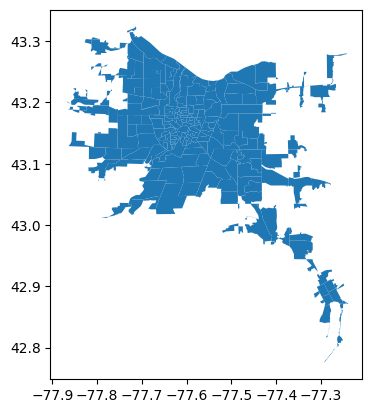

In [17]:
if not os.path.isdir("tracts_shapefile"):
    os.makedirs("tracts_shapefile")

# Cities that cross multiple state lines are seperated by multiple dashes
# e.g Seattle OR--WA
state = city_name.split(", ")[1]
census_tracts = gpd.GeoDataFrame()
for s in state.split("--"):
    # For each state in the city, extract the fips code (a two-digit number used to identify each US state and territory)
    fips_code = postal_to_fips[s]
    # Use string formatting to automatically download census tract shapefiles for each relevant state
    if not os.path.isdir(f"tracts_shapefile/{s}"):
        os.makedirs(f"tracts_shapefile/{s}")
        wget.download(f"https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_{fips_code}_tract_500k.zip", out=f"./tracts_shapefile/{s}")
    if census_tracts.empty:
        census_tracts = gpd.read_file(f"./tracts_shapefile/{s}/cb_2018_{fips_code}_tract_500k.zip")
    else:
        new_tracts = gpd.read_file(f"./tracts_shapefile/{s}/cb_2018_{fips_code}_tract_500k.zip")
        census_tracts = pd.concat([census_tracts, new_tracts])

# Extract the shapefile for the urban area from the earlier shapefile
city = gdf_cities[gdf_cities["NAME10"] == city_name]
# Get the intersection of the census tracts shapefile and the urban area shapefile
intersection = census_tracts.overlay(city, how="intersection")
f, ax = plt.subplots()
# Plot the intersection
intersection.plot(ax=ax)

In [18]:
city = gdf_cities[gdf_cities["NAME10"] == city_name]
# Get the bounding box of the urban area
bbox = city.bounds

bbox = bbox.values[0]
start_date = '2023-12-18'
end_date = '2023-12-20'

# Download the TEMPO data from the selected dates, over the selected area
# TODO: subset the TEMPO data by time as well, so only 11am-1pm local time is used
# Need to use overwrite = true because the tempo api will re-use files with incomplete data
api = pyrsig.RsigApi(bdate=start_date, edate=end_date, bbox=bbox, overwrite = True)
tempokey = 'tempo.l2.no2.vertical_column_troposphere'
api_key = 'anonymous'  # using public data, so using anonymous TODO: Determine limits of public data
api.tempo_kw['api_key'] = api_key

# Convert to a data frame
df = api.to_ioapi(tempokey)
df

<xarray.Dataset> Size: 108MB
Dimensions:          (TSTEP: 49, VAR: 4, DATE-TIME: 2, LAY: 1, ROW: 299,
                      COL: 459)
Coordinates:
  * TSTEP            (TSTEP) datetime64[ns] 392B 2023-12-18 ... 2023-12-20
  * LAY              (LAY) float32 4B 0.9975
  * ROW              (ROW) float64 2kB 0.5 1.5 2.5 3.5 ... 296.5 297.5 298.5
  * COL              (COL) float64 4kB 0.5 1.5 2.5 3.5 ... 456.5 457.5 458.5
Dimensions without coordinates: VAR, DATE-TIME
Data variables:
    TFLAG            (TSTEP, VAR, DATE-TIME) int32 2kB ...
    LONGITUDE        (TSTEP, LAY, ROW, COL) float32 27MB ...
    LATITUDE         (TSTEP, LAY, ROW, COL) float32 27MB ...
    COUNT            (TSTEP, LAY, ROW, COL) int32 27MB ...
    NO2_VERTICAL_CO  (TSTEP, LAY, ROW, COL) float32 27MB ...
Attributes: (12/34)
    IOAPI_VERSION:  1.0 1997349 (Dec. 15, 1997)
    EXEC_ID:        ????????????????                                         ...
    FTYPE:          1
    CDATE:          2025061
    CTIME:          230
    WDATE:          2025061
    ...             ...
    GDNAM:          M_02_99BRACE    
    UPNAM:          XDRConvert      
    VAR-LIST:       LONGITUDE       LATITUDE        COUNT           NO2_VERTI...
    FILEDESC:       http://tempo.si.edu/,TEMPOSubset,XDRConvert              ...
    HISTORY:        XDRConvert
    crs_proj4:      +proj=lcc +lat_1=33.0 +lat_2=45.0 +lat_0=40.0 +lon_0=-97....

<Axes: xlabel='COL', ylabel='ROW'>

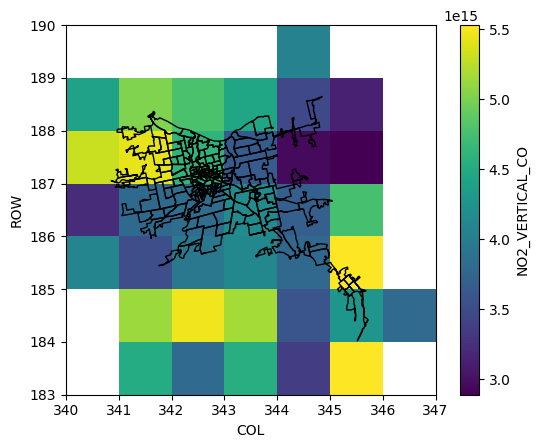

In [19]:
# Plot the time average
# This code is basically taken exactly from the TEMPO api tutorial, parts of this I don't really get
cno = pycno.cno(df.crs_proj4)
qm = df['NO2_VERTICAL_CO'].where(lambda x: x>0, drop=True).mean(('TSTEP', 'LAY')).plot()
intersection.to_crs(df.attrs['crs_proj4']).plot(ax=qm.axes, facecolor='none', edgecolor='k')